In [1]:
import anndata
import numpy as np
import gc
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850-imputed/20240831/C57BL6J-638850-imputed-log2-wmeta-ccf.h5ad'
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 3739961 × 8460
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x_section', 'y_section', 'z_section', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'x_reconstructed', 'y_reconstructed', 'z_reconstructed', 'parcellation_index', 'x_ccf', 'y_ccf', 'z_ccf', 'parcellation_organ', 'parcellation_category', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'parcellation_organ_color', 'parcellation_category_color', 'parcellation_division_color', 'parcellation_structure_color', 'parcellation_substructure_color'
    var: 'gene_symbol'

In [ ]:
# # Subsetting data to microglia

# # Define the specific subclass name to filter
# specific_subclass = '334 Microglia NN'

# # Filter cells based on the specific subclass
# microglia_ad = adata[adata.obs['subclass'] == specific_subclass].copy()
# print("Shape of filtered data: ", microglia_ad.shape)

In [4]:
# Load modules dataframe
modules_df = pd.read_csv(
    "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Microglia-raw-meta-wgcna-modules.csv",
    index_col = "Unnamed: 0")
print("All module colors (names): ", modules_df["color"].unique())

All module colors (names):  ['turquoise' 'grey' 'brown' 'blue' 'yellow']


## ME in all cells

In [17]:
def plot_pca(xx, yy, cc=None, val=None, adata=None, pc_component=None, 
                 fig_width=8, fig_height=8, cmap=None, cbar_label=None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    scatter_plot = None  # To hold the scatter plot object
    
    # PCA component coloring
    if pc_component is not None:
        if adata is None:
            raise ValueError("adata must be provided when using pc_component.")
        val = adata.obsm['X_pca'][:, pc_component]
        cmap = cmap or 'viridis'
        scatter_plot = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar_label = cbar_label or f'PC{pc_component + 1}'  # Auto-label for PCA
        
    # Regular colormap coloring
    elif cmap is not None:
        scatter_plot = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar_label = cbar_label or 'Value'  # Default label
        
    # Categorical color list
    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, color=cc, marker='.')
        
    # Default to black
    else:
        ax.scatter(xx, yy, s=0.5, color='k', marker='.')
    
    # Add color bar if needed
    if scatter_plot is not None:
        cbar = fig.colorbar(scatter_plot, ax=ax, shrink=0.6, aspect=10)
        if cbar_label:
            cbar.set_label(cbar_label, rotation=270, labelpad=15)
    
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')
    plt.title(f'Module Eigengene for module: {select_module}')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

In [ ]:
select_module = "yellow"
select_genes = modules_df[modules_df["module"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = adata.var_names.intersection(select_genes)
adata_subset = adata[:,common_genes].copy()
adata_subset.X = adata_subset.X.astype("float32")
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
adata_section = adata_subset[adata_subset.obs['brain_section_label'] == 'C57BL6J-638850.38']
plot_pca(adata_section.obs['x_reconstructed'], adata_section.obs['y_reconstructed'], adata=adata_section, pc_component=0, cmap='viridis')

/tmp/ipykernel_2416935/1140654524.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_pca_df = pca_df.groupby('class').mean()


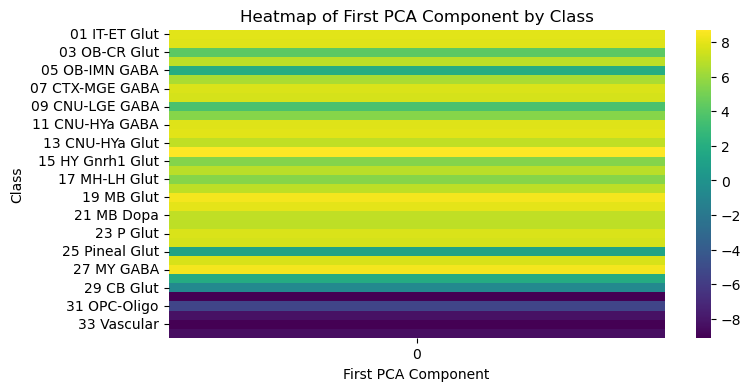

Top 10 subclasses with the highest mean value for the first PCA component:
class
14 HY Glut           8.722157
27 MY GABA           8.434464
19 MB Glut           8.390781
20 MB GABA           7.964190
12 HY GABA           7.935624
01 IT-ET Glut        7.931221
02 NP-CT-L6b Glut    7.886264
11 CNU-HYa GABA      7.836250
23 P Glut            7.701991
07 CTX-MGE GABA      7.681602
Name: 0, dtype: float32


In [20]:
# Create a DataFrame for the PCA components and class
pca_df = pd.DataFrame(adata_subset.obsm['X_pca'], index=adata_subset.obs.index)
pca_df['class'] = adata_subset.obs['class']

# Compute the mean PCA components for each subclass
mean_pca_df = pca_df.groupby('class').mean()

# Show only the first PCA component
plt.figure(figsize=(8, 4))
sns.heatmap(mean_pca_df[[0]], cmap='viridis', annot=False)
plt.title('Heatmap of First PCA Component by Class')
plt.xlabel('First PCA Component')
plt.ylabel('Class')
plt.show()

# Get the top 10 subclasses with the highest mean value for the first PCA component
top_10_active_subclasses = mean_pca_df[0].nlargest(10)
print("Top 10 subclasses with the highest mean value for the first PCA component:")
print(top_10_active_subclasses)

In [21]:
'''
Module specificity with Tau score
'''
# Shift the eigengene values to ensure non-negativity
tau_df = adata_subset.obs[["class"]].copy()
tau_df[select_module] = adata_subset.obsm['X_pca'][:,0]
tau_df[select_module] = tau_df[select_module] - tau_df[select_module].min() + 1e-6

# Compute average eigengene per cell class
avg_expression = tau_df.groupby('class', observed = False)[select_module].mean()

# Normalize by the maximum average expression
max_expr = avg_expression.max()
normalized_expr = avg_expression / max_expr

# Compute tau score
tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
print(f"Tau specificity score for the module: {tau:.3f}")

Tau specificity score for the module: 0.201
